In [5]:

CACHE_DIR = './cache'

In [7]:
import fastf1
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

def setup_fastf1(cache_dir):
    """Configure FastF1 settings"""
    fastf1.Cache.enable_cache(cache_dir)
    fastf1.plotting.setup_mpl()

def calculate_degradation(lap_times, compound):
    """Calculate tyre degradation metrics"""
    compound_laps = lap_times[lap_times['Compound'] == compound]
    
    if len(compound_laps) < 2:
        return None
    
    # Calculate rolling median to smooth outliers
    compound_laps['SmoothedLapTime'] = compound_laps['LapTime'].dt.total_seconds().rolling(
        window=3, center=True, min_periods=1).median()
    
    # Calculate degradation per lap (seconds)
    compound_laps['Degradation'] = compound_laps['SmoothedLapTime'].diff()
    
    return compound_laps

def plot_tyre_performance(driver_laps, compound, drivers=None):
    """Plot tyre performance for selected drivers"""
    if drivers is None:
        drivers = driver_laps['Driver'].unique()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for driver in drivers:
        driver_data = driver_laps[driver_laps['Driver'] == driver]
        if len(driver_data) == 0:
            continue
            
        stints = driver_data[['Driver', 'Stint', 'Compound', 'LapNumber']].groupby(
            ['Driver', 'Stint', 'Compound']).count().reset_index()
        stints = stints.rename(columns={'LapNumber': 'StintLength'})
        
        for _, stint in stints[stints['Compound'] == compound].iterrows():
            stint_laps = driver_data[driver_data['Stint'] == stint['Stint']]
            ax.plot(stint_laps['LapNumber'], 
                   stint_laps['LapTime'].dt.total_seconds(),
                   label=f"{driver} Stint {stint['Stint']}",
                   marker='o')
    
    ax.set_xlabel('Lap Number')
    ax.set_ylabel('Lap Time (s)')
    ax.set_title(f'Tyre Performance - {compound} Compound')
    ax.legend()
    ax.grid()
    plt.tight_layout()
    return fig

In [9]:
from fastf1 import get_session
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Constants with engineer's values
FUEL_CORRECTION_RATE = 0.03  # seconds per kg (0.3s per 10kg)
START_FUEL = 110  # kg (standard starting fuel)

def calculate_fuel_corrected_laptime(lap_number, lap_time_seconds, total_laps):
    """Adjust lap time for fuel load effect using engineer's method"""
    fuel_consumption_per_lap = START_FUEL / total_laps  # kg per lap
    fuel_remaining = START_FUEL - (lap_number * fuel_consumption_per_lap)
    fuel_correction = (START_FUEL - fuel_remaining) * FUEL_CORRECTION_RATE
    return lap_time_seconds - fuel_correction

def analyze_tyre_performance(laps, total_race_laps):
    """Calculate average lap times for all tyre compounds with 107% rule filtering"""
    # Get all accurate race laps (no pit in/out)
    race_laps = laps[(laps['IsAccurate'] == True) &
                   (laps['PitOutTime'].isna()) & 
                   (laps['PitInTime'].isna())].copy()
    
    # Apply fuel correction to all laps using engineer's method
    race_laps['LapTimeSeconds'] = race_laps['LapTime'].dt.total_seconds()
    race_laps['CorrectedLapTime'] = race_laps.apply(
        lambda x: calculate_fuel_corrected_laptime(x['LapNumber'], x['LapTimeSeconds'], total_race_laps),
        axis=1
    )
    
    # 107% Rule Filtering per compound
    clean_laps = []
    compound_stats = {}
    
    for compound, compound_laps in race_laps.groupby('Compound'):
        if len(compound_laps) < 2:  # Need at least 2 laps
            continue
            
        # Find fastest corrected lap time for this compound
        fastest_corrected = compound_laps['CorrectedLapTime'].min()
        cutoff_time = fastest_corrected * 1.07  # 107% of fastest
        
        # Filter laps within 107% of fastest
        clean_compound_laps = compound_laps[
            compound_laps['CorrectedLapTime'] <= cutoff_time
        ].copy()
        
        # Track statistics
        removed = len(compound_laps) - len(clean_compound_laps)
        compound_stats[compound] = {
            'original_count': len(compound_laps),
            'removed_count': removed,
            'fastest_time': fastest_corrected
        }
        
        if removed > 0:
            print(f"Removed {removed} laps (>107% of fastest) from {compound} compound")
            
        clean_laps.append(clean_compound_laps)
    
    # Combine all cleaned data
    clean_race_laps = pd.concat(clean_laps)
    
    # Calculate average lap times per compound
    avg_per_compound = clean_race_laps.groupby('Compound')['CorrectedLapTime'].agg(
        ['mean', 'std', 'count', 'median', 'min', 'max']
    ).rename(columns={
        'mean': 'AvgLapTime',
        'std': 'StdDev',
        'count': 'LapCount',
        'median': 'MedianLapTime',
        'min': 'BestLapTime',
        'max': 'WorstLapTime'
    })
    
    # Add compound statistics
    for compound in avg_per_compound.index:
        if compound in compound_stats:
            avg_per_compound.loc[compound, 'OriginalCount'] = compound_stats[compound]['original_count']
            avg_per_compound.loc[compound, 'RemovedCount'] = compound_stats[compound]['removed_count']
            avg_per_compound.loc[compound, 'FastestLapTime'] = compound_stats[compound]['fastest_time']
    
    # Calculate 95th percentile (remove extreme outliers)
    percentile_95 = clean_race_laps.groupby('Compound')['CorrectedLapTime'].quantile(0.95)
    avg_per_compound['P95LapTime'] = percentile_95
    
    # Convert to readable string format
    avg_per_compound['Formatted'] = avg_per_compound.apply(
        lambda x: f"{x['AvgLapTime']:.3f} ± {x['StdDev']:.3f}s (n={x['LapCount']})",
        axis=1
    )
    
    return avg_per_compound, clean_race_laps

def plot_compound_performance(avg_per_compound):
    """Plot comparison of compound performance"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Average lap times with error bars
    compounds = avg_per_compound.index
    avg_times = avg_per_compound['AvgLapTime']
    std_devs = avg_per_compound['StdDev']
    
    bars = ax1.bar(compounds, avg_times, yerr=std_devs, 
                   capsize=5, alpha=0.7, color=['red', 'yellow', 'white', 'blue'])
    ax1.set_xlabel('Tyre Compound')
    ax1.set_ylabel('Average Fuel-Corrected Lap Time (s)')
    ax1.set_title('Average Lap Time per Compound\n(with standard deviation)')
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (compound, row) in enumerate(avg_per_compound.iterrows()):
        ax1.text(i, row['AvgLapTime'] + row['StdDev'] + 0.1, 
                f"{row['AvgLapTime']:.3f}s", ha='center', fontweight='bold')
    
    # Lap count and data quality
    lap_counts = avg_per_compound['LapCount']
    original_counts = avg_per_compound.get('OriginalCount', lap_counts)
    
    x_pos = np.arange(len(compounds))
    width = 0.35
    
    ax2.bar(x_pos - width/2, original_counts, width, label='Original Laps', alpha=0.6)
    ax2.bar(x_pos + width/2, lap_counts, width, label='After 107% Filter', alpha=0.8)
    ax2.set_xlabel('Tyre Compound')
    ax2.set_ylabel('Number of Laps')
    ax2.set_title('Data Quality per Compound')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(compounds)
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    return fig

# Main analysis
session = get_session(2024, 'ABU DHABI', 'R')
session.load()
laps = session.laps
total_race_laps = session.total_laps

print("=== TYRE COMPOUND PERFORMANCE ANALYSIS ===")
print(f"Using engineer's fuel correction: {FUEL_CORRECTION_RATE:.3f}s/kg, {START_FUEL}kg start fuel")
print(f"Race distance: {total_race_laps} laps\n")

# 1. Analyze all compounds
print("\n1. Average Fuel-Corrected Lap Times per Compound (107% rule applied):")
avg_compound_times, clean_race_laps = analyze_tyre_performance(laps, total_race_laps)

# Display detailed results
for compound, row in avg_compound_times.iterrows():
    print(f"\n{compound}:")
    print(f"  Average: {row['AvgLapTime']:.3f} ± {row['StdDev']:.3f}s")
    print(f"  Best:    {row['BestLapTime']:.3f}s")
    print(f"  Median:  {row['MedianLapTime']:.3f}s")
    print(f"  P95:     {row.get('P95LapTime', 'N/A'):.3f}s")
    print(f"  Laps:    {row['LapCount']}/{row.get('OriginalCount', row['LapCount'])} (after filtering)")


plt.show()

req         WARNING 	DEFAULT CACHE ENABLED! (9.97 GB) /Users/joshzola/Library/Caches/fastf1
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '55', '16', '44', '63', '1', '10', '27', '14', '81', '23', '22', '24', '18', '6

=== TYRE COMPOUND PERFORMANCE ANALYSIS ===
Using engineer's fuel correction: 0.030s/kg, 110kg start fuel
Race distance: 58 laps


1. Average Fuel-Corrected Lap Times per Compound (107% rule applied):
Removed 3 laps (>107% of fastest) from HARD compound
Removed 37 laps (>107% of fastest) from MEDIUM compound
Removed 3 laps (>107% of fastest) from SOFT compound

HARD:
  Average: 87.320 ± 1.389s
  Best:    84.479s
  Median:  87.277s
  P95:     89.268s
  Laps:    649/652.0 (after filtering)

MEDIUM:
  Average: 88.729 ± 1.451s
  Best:    84.269s
  Median:  89.155s
  P95:     90.019s
  Laps:    208/245.0 (after filtering)

SOFT:
  Average: 86.763 ± 1.148s
  Best:    82.394s
  Median:  87.072s
  P95:     87.544s
  Laps:    21/24.0 (after filtering)


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '55', '16', '44', '63', '1', '10', '27', '14', '81', '23', '22', '24', '18', '61', '20', '30', '77', '43', '11']


Average HARD tyre degradation (signed): -0.068 s/lap
Average HARD tyre degradation (absolute): 0.068 s/lap
Based on 20 valid stints
Stints showing degradation: 0
Stints showing improvement: 20

Individual stint results:
Driver  Stint  DegradationRate  AbsDegradationRate     Trend  RSquared  StintLength
   ALB    2.0        -0.058432            0.058432 Improving  0.731351           39
   ALO    2.0        -0.047929            0.047929 Improving  0.695309           22
   ALO    3.0        -0.071636            0.071636 Improving  0.662683           20
   DOO    2.0        -0.079881            0.079881 Improving  0.788654           32
   GAS    2.0        -0.067691            0.067691 Improving  0.875086           40
   HAM    1.0        -0.083041            0.083041 Improving  0.858082           30
   HUL    2.0        -0.061013            0.061013 Improving  0.878749           42
   LAW    4.0        -0.087633            0.087633 Improving  0.889698           23
   LEC    2.0        -0.

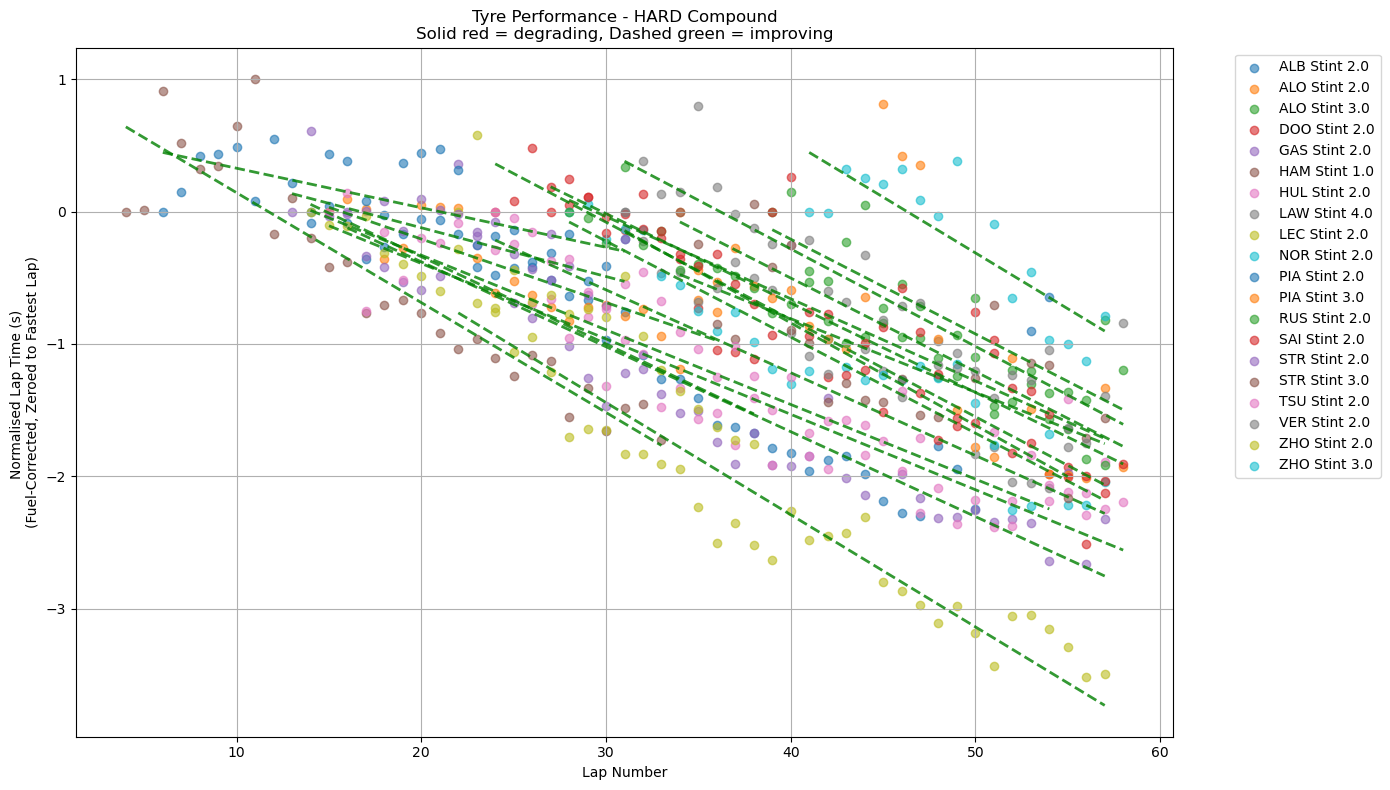

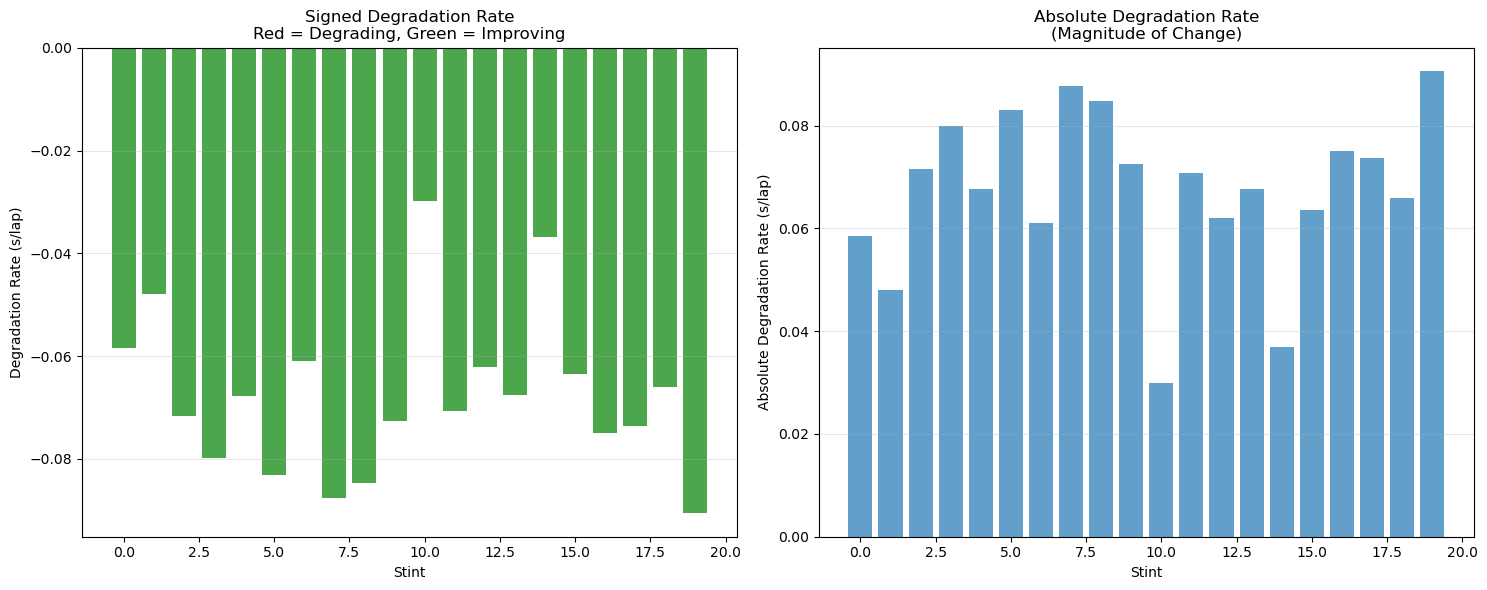

In [11]:
from fastf1 import get_session
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Constants with engineer's values
FUEL_CORRECTION_RATE = 0.03  # seconds per 10kg is 0.3s -> 0.03s per kg
START_FUEL = 110  # kg (standard starting fuel)
TYRE_COMPOUND = 'HARD'

def calculate_fuel_corrected_laptime(lap_number, lap_time_seconds, total_laps):
    """Adjust lap time for fuel load effect using engineer's method"""
    fuel_consumption_per_lap = START_FUEL / total_laps  # kg per lap
    fuel_remaining = START_FUEL - (lap_number * fuel_consumption_per_lap)
    fuel_used = lap_number * (START_FUEL / total_race_laps)
    fuel_correction = fuel_used * FUEL_CORRECTION_RATE
    return lap_time_seconds - fuel_correction



def calculate_degradation_engineer_method(stint_laps, total_race_laps):
    """Calculate tyre degradation using the engineer's preferred method"""
    if len(stint_laps) < 3:  # Need more laps for meaningful regression
        return None, None, None, None
    
    # Convert lap times to seconds
    stint_laps = stint_laps.copy()
    stint_laps['LapTimeSeconds'] = stint_laps['LapTime'].dt.total_seconds()
    
    # Apply fuel correction using race distance
    stint_laps['CorrectedLapTime'] = stint_laps.apply(
        lambda x: calculate_fuel_corrected_laptime(x['LapNumber'], x['LapTimeSeconds'], total_race_laps),
        axis=1
    )
    
    # Normalize to zero around the fastest lap
    start_time = stint_laps['CorrectedLapTime'].iloc[0]
    stint_laps['NormalizedTime'] = stint_laps['CorrectedLapTime'] - start_time

    
    # Remove outliers - engineer's method
    # Filter out laps where driver goes quicker next lap (suggesting current lap was a mistake)
    valid_indices = []
    normalized_times = stint_laps['NormalizedTime'].values
    
    valid_indices = []
    norm = stint_laps['NormalizedTime'].values
    
    for i in range(len(norm)):
        # keep if it's within 0.7s of adjacent laps
        if (
            (i > 0 and abs(norm[i] - norm[i-1]) < 0.7) or 
            (i < len(norm)-1 and abs(norm[i] - norm[i+1]) < 0.7)
        ):
            valid_indices.append(i)


    
    cleaned_laps = stint_laps.iloc[valid_indices].copy()
    
    if len(cleaned_laps) < 10:
        return None, None, None, None
    
    # Prepare for linear regression
    X = np.arange(len(cleaned_laps)).reshape(-1, 1) # Lap numbers as feature
    y = cleaned_laps['NormalizedTime'].values  # Normalized times as target
    
    # Perform linear regression
    model = LinearRegression()
    model.fit(X, y)
    
    degradation_per_lap = model.coef_[0]  # Signed degradation rate (seconds/lap)
    abs_degradation_per_lap = abs(degradation_per_lap)  # Absolute degradation rate
    r_squared = model.score(X, y)
    
    return degradation_per_lap, abs_degradation_per_lap, r_squared, cleaned_laps

def plot_tyre_performance_with_trend(laps, compound, drivers=None):
    """Plot fuel-corrected tyre performance with degradation trends"""
    if drivers is None:
        drivers = laps['Driver'].unique()
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    for driver in drivers:
        driver_data = laps[laps['Driver'] == driver].copy()
        if len(driver_data) == 0:
            continue
            
        stints = driver_data[['Driver', 'Stint', 'Compound', 'LapNumber']].groupby(
            ['Driver', 'Stint', 'Compound']).count().reset_index()
        stints = stints.rename(columns={'LapNumber': 'StintLength'})
        
        for _, stint in stints[stints['Compound'] == compound].iterrows():
            stint_laps = driver_data[driver_data['Stint'] == stint['Stint']]
            
            # Plot individual laps
            ax.scatter(stint_laps['LapNumber'], 
                      stint_laps['NormalizedTime'],
                      alpha=0.6,
                      label=f"{driver} Stint {stint['Stint']}")
            
            # Plot trend line if we have enough data
            if len(stint_laps) > 2:
                X = stint_laps['LapNumber'].values.reshape(-1, 1)
                y = stint_laps['NormalizedTime'].values
                
                try:
                    model = LinearRegression()
                    model.fit(X, y)
                    trend_line = model.predict(X)
                    
                    # Color code based on degradation direction
                    color = 'red' if model.coef_[0] > 0 else 'green'
                    linestyle = '-' if model.coef_[0] > 0 else '--'
                    
                    ax.plot(stint_laps['LapNumber'], trend_line, linestyle, 
                           color=color, alpha=0.8, linewidth=2)
                except:
                    pass
    
    ax.set_xlabel('Lap Number')
    ax.set_ylabel('Normalised Lap Time (s) \n(Fuel-Corrected, Zeroed to Fastest Lap)')
    ax.set_title(f'Tyre Performance - {compound} Compound\nSolid red = degrading, Dashed green = improving')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid()
    plt.tight_layout()
    return fig

def plot_degradation_comparison(degradation_df):
    """Plot comparison of signed vs absolute degradation rates"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Signed degradation (shows direction)
    colors = ['red' if x > 0 else 'green' for x in degradation_df['DegradationRate']]
    ax1.bar(range(len(degradation_df)), degradation_df['DegradationRate'], color=colors, alpha=0.7)
    ax1.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax1.set_xlabel('Stint')
    ax1.set_ylabel('Degradation Rate (s/lap)')
    ax1.set_title('Signed Degradation Rate\nRed = Degrading, Green = Improving')
    ax1.grid(axis='y', alpha=0.3)
    
    # Absolute degradation (shows magnitude)
    ax2.bar(range(len(degradation_df)), degradation_df['AbsDegradationRate'], alpha=0.7)
    ax2.set_xlabel('Stint')
    ax2.set_ylabel('Absolute Degradation Rate (s/lap)')
    ax2.set_title('Absolute Degradation Rate\n(Magnitude of Change)')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    return fig

# Main analysis
session = get_session(2024, 'ABU DHABI', 'R')
session.load()
total_race_laps = session.total_laps  # Get actual race distance

# Get and filter laps
laps = session.laps
compound_laps = laps[(laps['Compound'] == TYRE_COMPOUND) & 
                    (laps['IsAccurate'] == True) &
                    (laps['PitOutTime'].isna()) & 
                    (laps['PitInTime'].isna())].copy()

# Calculate degradation using engineer's method
degradation_results = []
valid_stints = []

for (driver, stint), stint_laps in compound_laps.groupby(['Driver', 'Stint']):
    deg_rate, abs_deg_rate, r_squared, cleaned_laps = calculate_degradation_engineer_method(stint_laps, total_race_laps)
    
    if deg_rate is not None and r_squared > 0.3:  # Minimum fit quality
        degradation_results.append({
            'Driver': driver,
            'Stint': stint,
            'DegradationRate': deg_rate,
            'AbsDegradationRate': abs_deg_rate,
            'RSquared': r_squared,
            'StintLength': len(cleaned_laps),
            'Trend': 'Degrading' if deg_rate > 0 else 'Improving'
        })
        cleaned_laps['Driver'] = driver
        cleaned_laps['Stint'] = stint
        valid_stints.append(cleaned_laps)

if not degradation_results:
    print(f"No valid {TYRE_COMPOUND} tyre stints found with good degradation trends.")
    import sys
    sys.exit(1)

# Combine all valid processed laps for plotting
all_processed_laps = pd.concat(valid_stints)

# Calculate average degradation (both signed and absolute)
degradation_df = pd.DataFrame(degradation_results)
avg_signed_degradation = degradation_df['DegradationRate'].mean()
avg_absolute_degradation = degradation_df['AbsDegradationRate'].mean()

print(f"Average {TYRE_COMPOUND} tyre degradation (signed): {avg_signed_degradation:.3f} s/lap")
print(f"Average {TYRE_COMPOUND} tyre degradation (absolute): {avg_absolute_degradation:.3f} s/lap")
print(f"Based on {len(degradation_df)} valid stints")
print(f"Stints showing degradation: {len(degradation_df[degradation_df['DegradationRate'] > 0])}")
print(f"Stints showing improvement: {len(degradation_df[degradation_df['DegradationRate'] < 0])}")

print("\nIndividual stint results:")
print(degradation_df[['Driver', 'Stint', 'DegradationRate', 'AbsDegradationRate', 'Trend', 'RSquared', 'StintLength']].to_string(index=False))

# Plot and save results
fig1 = plot_tyre_performance_with_trend(all_processed_laps, TYRE_COMPOUND)
plt.savefig(f'_{TYRE_COMPOUND}_performance_with_trends.png', bbox_inches='tight')

fig2 = plot_degradation_comparison(degradation_df)
plt.savefig(f'_{TYRE_COMPOUND}_degradation_comparison.png', bbox_inches='tight')

plt.show()

all_processed_laps.to_csv(f'_{TYRE_COMPOUND}_degradation_engineer_method.csv', index=False)
degradation_df.to_csv(f'_{TYRE_COMPOUND}_degradation_summary.csv', index=False)
